<a href="https://colab.research.google.com/github/realfeeds/MSML/blob/main/Eksperimen_SML_Domu-Fidelis/Eksperimen_Domu_Fidelis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [31]:
#Type your code here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from joblib import dump

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [32]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [33]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [34]:
# missing values
display((df.drop(columns=['Outcome']) == 0).sum())

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


<Axes: xlabel='Outcome', ylabel='count'>

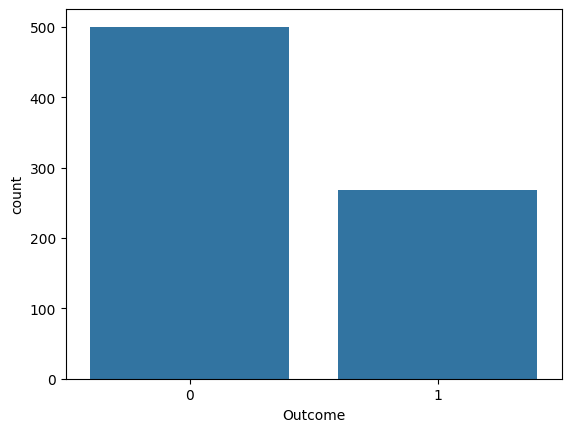

In [35]:
# check balance between classes
sns.countplot(x='Outcome', data=df)

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

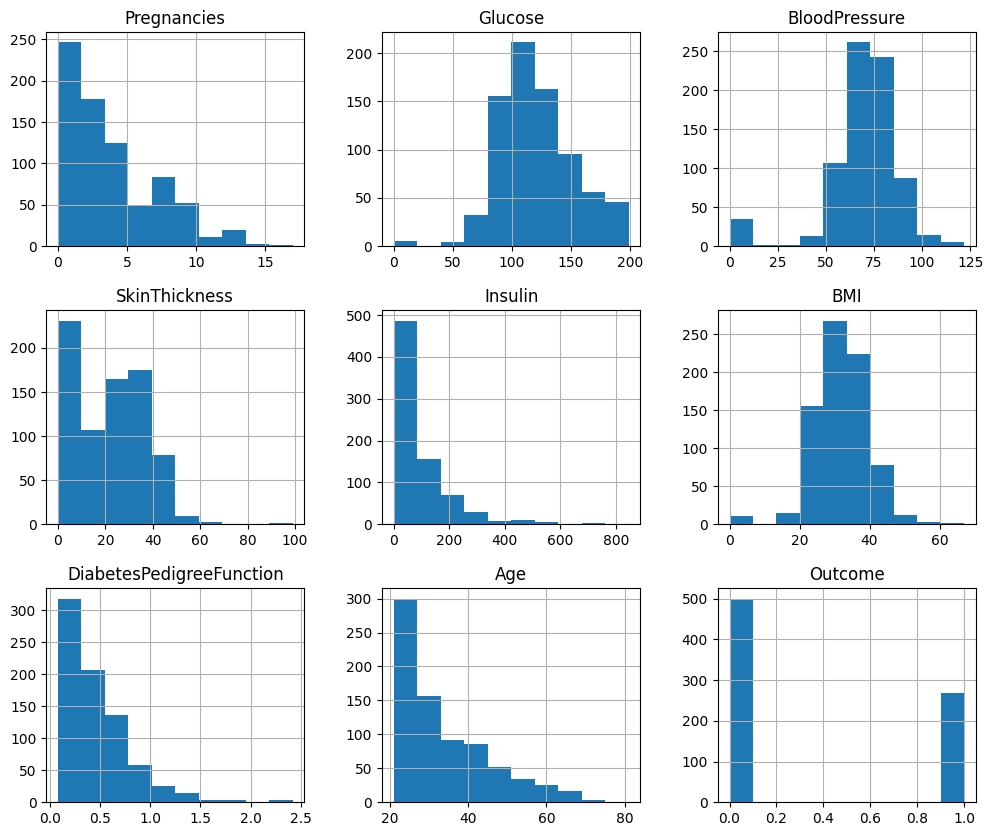

In [36]:
# plot
df.hist(figsize=(12,10))

<Axes: >

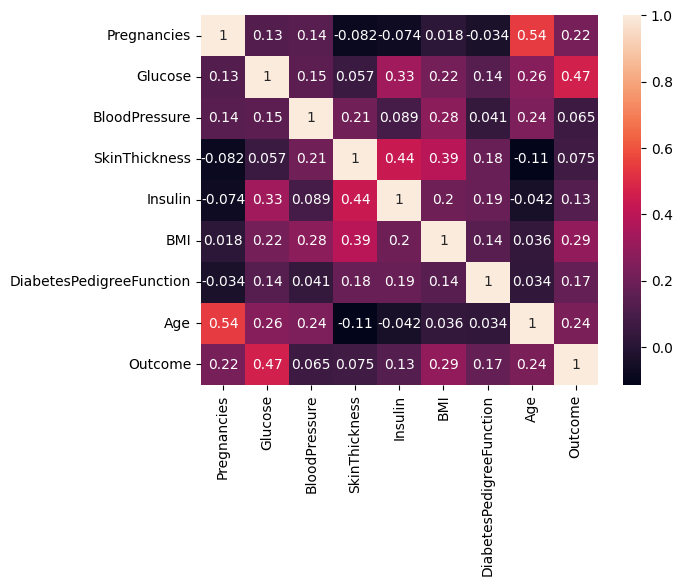

In [37]:
# correlation
sns.heatmap(df.corr(), annot=True)

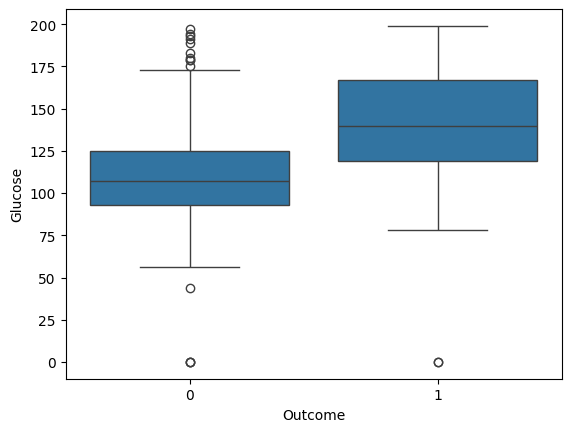

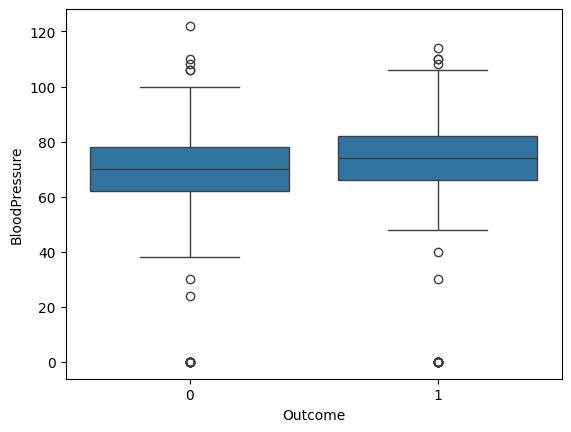

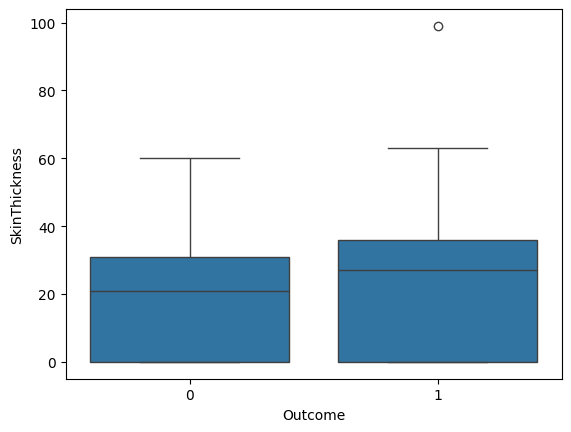

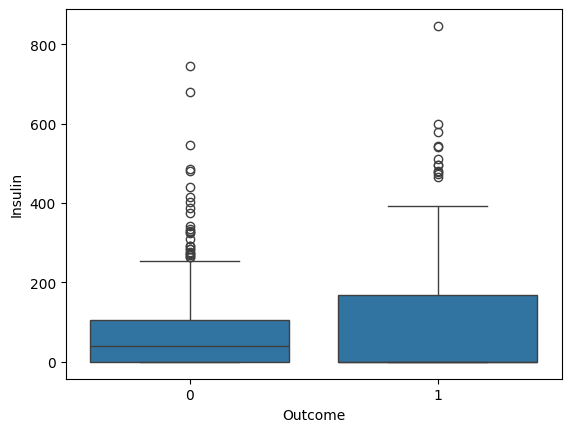

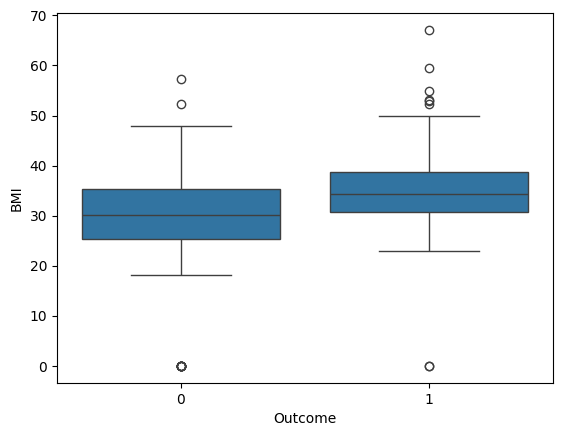

In [38]:
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
  sns.boxplot(x='Outcome', y=col, data=df)
  plt.show()

In [39]:
df_grouped = df.groupby('Outcome').agg(['mean', 'median'])
display(df_grouped.T)

Outcome                                   0           1
Pregnancies              mean      3.298000    4.865672
                         median    2.000000    4.000000
Glucose                  mean    109.980000  141.257463
                         median  107.000000  140.000000
BloodPressure            mean     68.184000   70.824627
                         median   70.000000   74.000000
SkinThickness            mean     19.664000   22.164179
                         median   21.000000   27.000000
Insulin                  mean     68.792000  100.335821
                         median   39.000000    0.000000
BMI                      mean     30.304200   35.142537
                         median   30.050000   34.250000
DiabetesPedigreeFunction mean      0.429734    0.550500
                         median    0.336000    0.449000
Age                      mean     31.190000   37.067164
                         median   27.000000   36.000000

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [40]:
cont_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] # kolom yg nol dianggap missing
df[cont_cols] = df[cont_cols].replace(0,np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [41]:
imputer = SimpleImputer(strategy='median')
df[cont_cols] = imputer.fit_transform(df[cont_cols])
df.isnull().sum()
print("Missing values handled using SimpleImputer")

Missing values handled using SimpleImputer


In [42]:
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")
print("Duplicates handled")

Shape after dropping duplicates: (768, 9)
Duplicates handled


In [43]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Data split")

Data split


In [45]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data scaled")

Data scaled


In [46]:
df_train_preprocessed = pd.DataFrame(
    X_train,
    columns=X.columns
)

df_test_preprocessed = pd.DataFrame(
    X_test,
    columns=X.columns
)

df_train_preprocessed["Outcome"] = y_train.reset_index(drop=True)
df_test_preprocessed["Outcome"] = y_test.reset_index(drop=True)

df_train_preprocessed.to_csv(
    "df_train_preprocessed.csv",
    index=False
)

df_test_preprocessed.to_csv(
    "df_test_preprocessed.csv",
    index=False
)

print("Preprocessed train and test datasets saved successfully")

Preprocessed train and test datasets saved successfully


In [47]:
dump(scaler, "scaler.pkl")
print('Saved scaler')

Saved scaler
